# Reconstructed fingerprint feature-extraction laboratory

This notebook is the ordered, executable reconstruction of the useful computer-vision branch in the legacy 483-cell laboratory notebook. It extracts a conservative set of ridge endings/bifurcations and experimental core/delta candidates from the single supplied image `1.jpg`.

**Scope boundary:** one-image research regression only; no AFIS performance claim; no ISO/IEC template is generated; singularity branch directions remain experimental.

In [1]:
from pathlib import Path
import sys, json
import cv2
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve()
if not (ROOT / 'src').exists():
    raise RuntimeError('Execute this notebook with the repository root as the working directory.')
sys.path.insert(0, str(ROOT / 'src'))

from fingerprint_pipeline import (
    PipelineConfig, run_pipeline, draw_orientation_field,
    draw_minutiae_branches, draw_singular_points, save_result_tables
)
print('Repository root detected:', ROOT.name)

Repository root detected: fingerprint_feature_extraction_reverse_engineering_v1_0_0


## 1. Fixed configuration

All thresholds are centralized. No package installation or Google Drive mounting occurs inside the notebook.

In [2]:
cfg = PipelineConfig()
pd.DataFrame([cfg.__dict__]).T.rename(columns={0: 'value'})

,value
block_size,16
clahe_clip_limit,2.0
clahe_grid,"(8, 8)"
orientation_smooth_sigma_blocks,1.0
roi_dark_threshold,248
roi_close_size,19
roi_erode_px,25
adaptive_block_size,31
adaptive_c,7
morph_kernel_size,1


## 2. Ordered execution

`run_pipeline` performs loading, CLAHE, ROI segmentation, orientation/coherence, Otsu ridge binarization, skeletonization, crossing-number candidates, branch tracing, conservative filtering, and Poincare singularity detection.

In [3]:
result = run_pipeline(ROOT / 'images/input/1.jpg', cfg)
out_dir = ROOT / 'results'
save_result_tables(result, out_dir)
print(json.dumps(result.diagnostics, indent=2))

{
  "image_shape": [
    400,
    275
  ],
  "configuration": {
    "block_size": 16,
    "clahe_clip_limit": 2.0,
    "clahe_grid": [
      8,
      8
    ],
    "orientation_smooth_sigma_blocks": 1.0,
    "roi_dark_threshold": 248,
    "roi_close_size": 19,
    "roi_erode_px": 25,
    "adaptive_block_size": 31,
    "adaptive_c": 7,
    "morph_kernel_size": 1,
    "min_component_size": 24,
    "prune_length": 5,
    "minutia_roi_distance": 38.0,
    "minutia_min_coherence": 0.4,
    "minutia_min_separation": 20.0,
    "branch_trace_length": 18,
    "branch_min_length": 15,
    "broken_ridge_pair_max_gap": 24.0,
    "broken_ridge_pair_angle_tolerance_deg": 35.0,
    "singular_search_radius_px": 10,
    "singular_ring_radius_px": 10,
    "singular_min_coherence": 0.12
  },
  "otsu_threshold": 153.0,
  "binary_foreground_pixels": 30061,
  "skeleton_pixels": 7761,
  "pruned_skeleton_pixels": 75,
  "prune_iterations": 1,
  "raw_crossing_number_candidates": 436,
  "candidate_clusters": 330,

## 3. Scientific processing stages

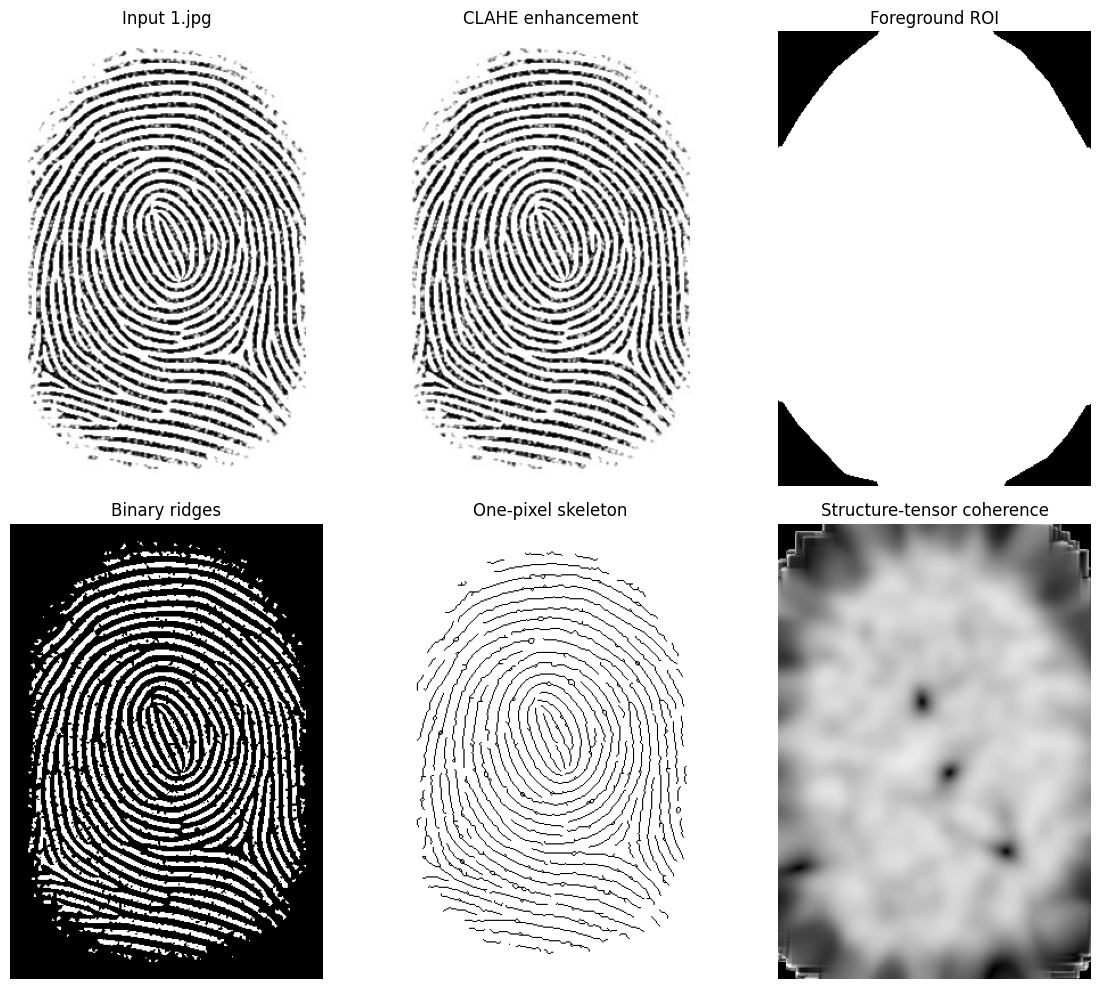

In [4]:
fig, ax = plt.subplots(2, 3, figsize=(12, 10))
stages = [
    (result.original, 'Input 1.jpg'),
    (result.enhanced, 'CLAHE enhancement'),
    (result.roi_mask, 'Foreground ROI'),
    (result.binary_ridges, 'Binary ridges'),
    (255-result.skeleton, 'One-pixel skeleton'),
    (result.coherence_dense, 'Structure-tensor coherence'),
]
for a, (im, title) in zip(ax.ravel(), stages):
    a.imshow(im, cmap='gray')
    a.set_title(title)
    a.axis('off')
plt.tight_layout()
plt.show()

## 4. Orientation field

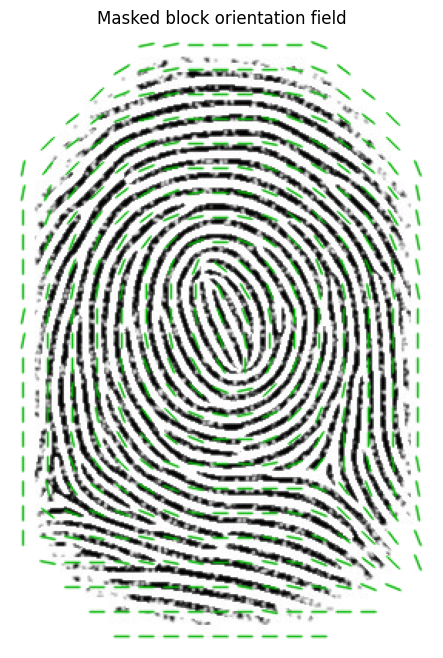

In [5]:
orientation_overlay = draw_orientation_field(
    result.enhanced, result.orientation_blocks, result.coherence_blocks, cfg
)
plt.figure(figsize=(6,8))
plt.imshow(cv2.cvtColor(orientation_overlay, cv2.COLOR_BGR2RGB))
plt.axis('off'); plt.title('Masked block orientation field'); plt.show()

## 5. Minutiae and skeleton-derived branches

Red marks are endings; blue marks are bifurcations. Green rays are traced from the skeleton and therefore carry a 0-to-2pi direction, unlike an undirected block orientation axis.

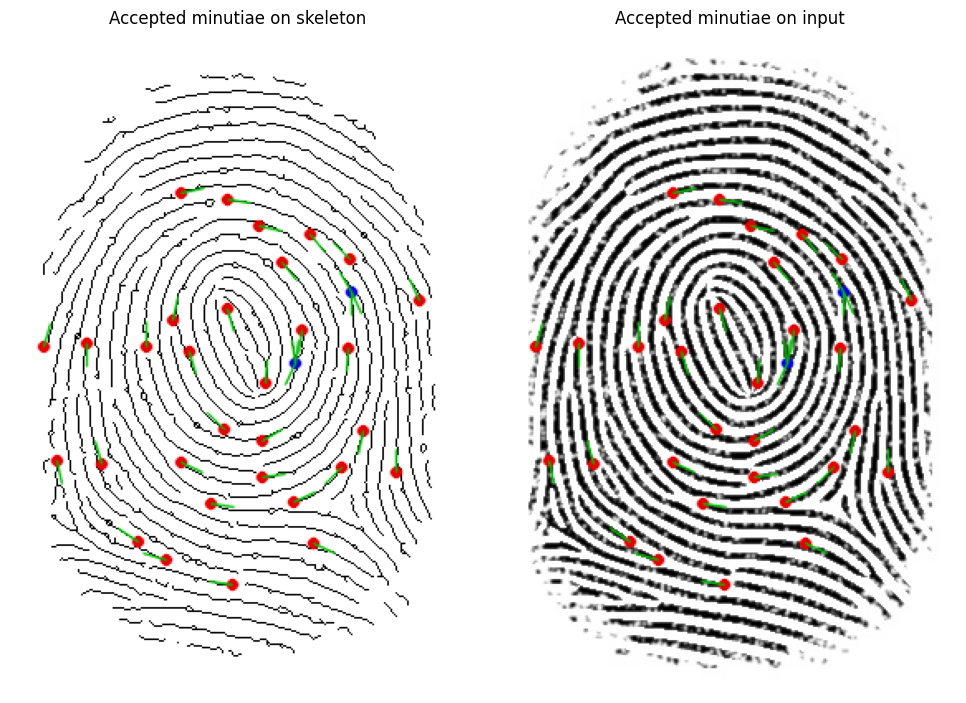

,x,y,kind,orientation_rad,branch_angles_rad,branch_lengths_px,coherence,roi_distance_px,quality_proxy
0,103,97,ending,6.075689,[6.07568908],[18],0.783632,55.9783,0.880998
1,131,101,ending,0.148890,[0.14888995],[18],0.785842,78.4000,0.882213
2,150,117,ending,0.231091,[0.23109067],[18],0.789889,85.6791,0.884439
3,181,122,ending,0.866302,[0.86630226],[18],0.773886,61.9225,0.875637
4,205,137,ending,3.898427,[3.89842716],[18],0.797937,48.9349,0.888865
5,164,139,ending,0.866302,[0.86630226],[18],0.747189,84.6884,0.860954
6,206,157,bifurcation,1.086318,"[1.0863184, 1.52321322, 4.17196948]","[18, 18, 18]",0.792218,59.7907,0.885720
7,247,162,ending,4.267970,[4.26796977],[18],0.725022,39.3473,0.848762
8,131,167,ending,1.234122,[1.23412151],[18],0.553668,117.0388,0.754517
9,98,174,ending,4.943480,[4.94347965],[18],0.785364,94.5535,0.881950


In [6]:
min_input = draw_minutiae_branches(result.original, result.minutiae)
min_skeleton = draw_minutiae_branches(255-result.skeleton, result.minutiae)
fig, ax = plt.subplots(1,2,figsize=(10,7))
for a, im, title in [
    (ax[0], min_skeleton, 'Accepted minutiae on skeleton'),
    (ax[1], min_input, 'Accepted minutiae on input'),
]:
    a.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB)); a.set_title(title); a.axis('off')
plt.tight_layout(); plt.show()
pd.read_csv(out_dir/'minutiae.csv').head(12)

## 6. Core/delta candidates and experimental topology arms

Yellow symbols are core candidates and cyan symbols are delta candidates. The point locations come from block Poincare candidates refined on a dense orientation field. The rays are visualization cues inferred from local ring alignment; they are not externally validated directions.

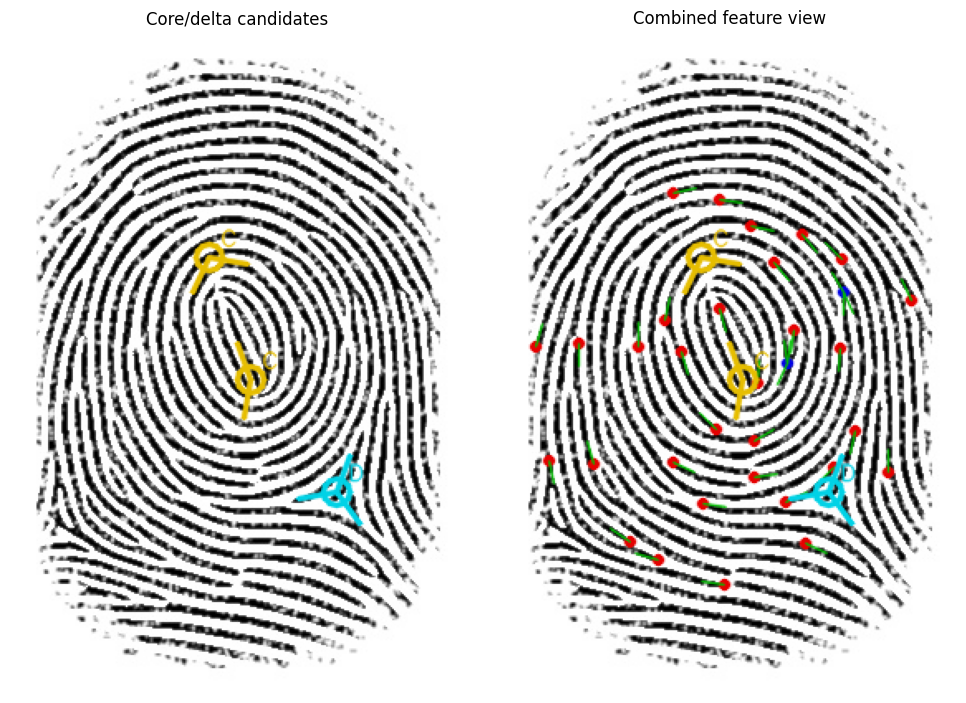

,x,y,kind,poincare_index_rad,branch_angles_rad,coherence
0,120,136,core,3.141593,"[0.20943951, 2.02458193]",0.749739
1,145,210,core,3.141593,"[1.78023584, 4.32841654]",0.597307
2,197,278,delta,-3.141593,"[0.9424778, 2.93215314, 5.09636142]",0.542608


In [7]:
sing = draw_singular_points(result.original, result.singular_points)
combined = draw_singular_points(min_input, result.singular_points)
fig, ax = plt.subplots(1,2,figsize=(10,7))
for a, im, title in [
    (ax[0], sing, 'Core/delta candidates'),
    (ax[1], combined, 'Combined feature view'),
]:
    a.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB)); a.set_title(title); a.axis('off')
plt.tight_layout(); plt.show()
pd.read_csv(out_dir/'singular_points.csv')

## 7. Interpreting this single-image result

The current strict configuration returns fewer points than the early notebook. It rejects boundary candidates, low-coherence points, junctions without exactly the expected number of long arms, near duplicates, and facing endpoint pairs caused by broken ridges. This is intended to reduce obvious noise, but it is **not proof of better accuracy** without expert ground truth.

The supplied whorl-like image yields two core candidates and one visible delta candidate. Their positions remain sensitive to block size, orientation smoothing, and the local refinement ring. This directly matches the historical observation that singularity type was plausible while exact placement and arm direction remained weak.

## 8. Legacy blocks kept and blocks quarantined

See `docs/legacy_cell_audit.md` for all 483 cells and `docs/block_execution_order.md` for the canonical order.

The ISO/FMR cells are intentionally excluded. The notebook mixed 2005 and 2011 assumptions, used a simplified private header/record layout, and validated the file with a parser built from the same assumptions. That establishes internal round-trip consistency only. A standards claim requires the official specification and an independent conformance suite such as BioCTS.